<a href="https://colab.research.google.com/github/George1902/analisis_imperios_historicos/blob/main/Analisis_Imperios_Historicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ascenso y Caída de los Grandes Imperios de la Historia
**Autor:** Jorge Ojeda  
**Fecha:** Marzo 2026  
**Fuente de datos:** Kaggle — World Empires Dataset

## Objetivo
Analizar la evolución temporal de los grandes imperios de la
historia, identificar patrones en su duración, expansión
territorial y conflictos bélicos usando series de tiempo
y visualizaciones históricas.

## Preguntas que responde este análisis
- ¿Cuánto duró cada gran imperio?
- ¿En qué períodos históricos hubo más imperios simultáneos?
- ¿Qué regiones del mundo concentraron más poder imperial?
- ¿Existe correlación entre guerras y caída de imperios?
- ¿Hay patrones temporales en el colapso de civilizaciones?

# Fase 1 — Exploración Inicial

## Montar Drive e importar librerías

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("✅ Librerías cargadas correctamente")

Mounted at /content/drive
✅ Librerías cargadas correctamente


## Cargar dataset de imperios

In [2]:
# Cargar dataset principal
ruta_imperios = '/content/drive/MyDrive/Colab Notebooks/imperios.csv'
df = pd.read_csv(ruta_imperios)

print(f"✅ Dataset cargado: {df.shape[0]} imperios, {df.shape[1]} columnas")
print("\n=== PRIMERAS FILAS ===")
display(df.head(10))

✅ Dataset cargado: 1536 imperios, 13 columnas

=== PRIMERAS FILAS ===


,empire,empire_start,empire_end,god,king,coin,trade,country_name,country_iso,geo,begin,end,capital
0,Achaemenid Empire,-550,-330,1,1,1,NaN,Afghanistan,AFG,Asia,-530,-331,0.0
1,Achaemenid Empire,-550,-330,1,1,1,NaN,United Arab Emirates,ARE,Asia,-530,-331,0.0
2,Achaemenid Empire,-550,-330,1,1,1,NaN,Armenia,ARM,Asia,-550,-331,0.0
3,Achaemenid Empire,-550,-330,1,1,1,NaN,Azerbaijan,AZE,Asia,-550,-331,0.0
4,Achaemenid Empire,-550,-330,1,1,1,NaN,Bulgaria,BGR,Europe,-512,-479,0.0
5,Achaemenid Empire,-550,-330,1,1,1,NaN,Egypt,EGY,Africa,-525,-404,0.0
6,Achaemenid Empire,-550,-330,1,1,1,NaN,Georgia,GEO,Asia,-550,-331,0.0
7,Achaemenid Empire,-550,-330,1,1,1,NaN,Greece,GRC,Europe,-512,-479,0.0
8,Achaemenid Empire,-550,-330,1,1,1,NaN,Iran,IRN,Asia,-550,-331,1.0
9,Achaemenid Empire,-550,-330,1,1,1,NaN,Iraq,IRQ,Asia,-539,-331,0.0


## Explorar columnas disponibles

In [3]:
print("=== COLUMNAS DISPONIBLES ===")
for col in df.columns:
    print(f"  {col}: {df[col].dtype} — ejemplo: {df[col].iloc[0]}")

=== COLUMNAS DISPONIBLES ===
  empire: object — ejemplo: Achaemenid Empire
  empire_start: int64 — ejemplo: -550
  empire_end: int64 — ejemplo: -330
  god: int64 — ejemplo: 1
  king: int64 — ejemplo: 1
  coin: int64 — ejemplo: 1
  trade: float64 — ejemplo: nan
  country_name: object — ejemplo: Afghanistan
  country_iso: object — ejemplo: AFG
  geo: object — ejemplo: Asia
  begin: int64 — ejemplo: -530
  end: int64 — ejemplo: -331
  capital: float64 — ejemplo: 0.0


## Estadísticas básicas

In [4]:
print("=== ESTADÍSTICAS GENERALES ===")
display(df.describe())

print("\n=== VALORES NULOS ===")
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0])

=== ESTADÍSTICAS GENERALES ===


,empire_start,empire_end,god,king,coin,trade,begin,end,capital
count,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,305.000000,1536.000000,1536.000000,1532.000000
mean,817.783854,1143.330729,0.255859,0.966797,0.462891,0.642623,899.205078,1108.736328,0.110313
std,858.562956,808.631854,0.436485,0.179225,0.498783,0.480015,833.894553,800.519318,0.313382
min,-2500.000000,-2150.000000,0.000000,0.000000,0.000000,0.000000,-2500.000000,-2150.000000,0.000000
25%,395.000000,651.000000,0.000000,1.000000,0.000000,0.000000,408.000000,650.000000,0.000000
50%,1037.000000,1279.000000,0.000000,1.000000,0.000000,1.000000,1037.000000,1258.000000,0.000000
75%,1501.000000,1904.750000,1.000000,1.000000,1.000000,1.000000,1575.000000,1823.000000,0.000000
max,1933.000000,2007.000000,1.000000,1.000000,1.000000,1.000000,1943.000000,2007.000000,1.000000



=== VALORES NULOS ===


,Nulos,Porcentaje (%)
trade,1231,80.14
capital,4,0.26


## ✅ Conclusiones de la Fase 1 — Exploración Inicial

- El dataset contiene 1536
- Las columnas clave disponibles son: 13
- Los imperios más antiguos datan de: -550 a.c.
- Valores nulos encontrados en: trade	1231	- 80.14 /
capital	4	- 0.26

**Siguiente fase:** Limpieza y preparación de datos

# Fase 2 — Limpieza y Preparación de Datos

En esta fase vamos a:
- Limpiar valores nulos
- Calcular duración de cada imperio
- Crear dataset consolidado por imperio
- Clasificar imperios por era histórica
- Preparar datos para series de tiempo

## Limpiar y calcular duración

In [5]:
# Rellenar nulos numéricos con 0
df['trade'] = df['trade'].fillna(0)
df['capital'] = df['capital'].fillna(0)

# Calcular duración de cada imperio
df['duracion'] = df['empire_end'] - df['empire_start']

print("✅ Datos limpiados")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

✅ Datos limpiados
Nulos restantes: 0


## Crear dataset consolidado por imperio

In [6]:
# Un registro por imperio con sus características principales
df_imperios = df.groupby('empire').agg(
    inicio        = ('empire_start', 'first'),
    fin           = ('empire_end', 'first'),
    duracion      = ('duracion', 'first'),
    territorios   = ('country_name', 'count'),
    regiones      = ('geo', 'nunique'),
    tenia_rey     = ('king', 'max'),
    tenia_moneda  = ('coin', 'max'),
    tenia_dios    = ('god', 'max'),
    tenia_comercio= ('trade', 'max')
).reset_index()

# Ordenar por inicio
df_imperios = df_imperios.sort_values('inicio').reset_index(drop=True)

print(f"✅ Dataset consolidado: {len(df_imperios)} imperios únicos")
display(df_imperios.head(10))

✅ Dataset consolidado: 168 imperios únicos


,empire,inicio,fin,duracion,territorios,regiones,tenia_rey,tenia_moneda,tenia_dios,tenia_comercio
0,Elam,-2500,-539,1961,2,1,1,0,0,0.0
1,Akkadian Empire,-2350,-2150,200,7,1,1,0,0,1.0
2,Neo-Sumerian (Ur III) Empire,-2112,-2004,108,4,1,1,0,1,1.0
3,Hittite Empire,-1600,-1178,422,3,1,1,0,1,0.0
4,Egyptian Empire,-1552,-1069,483,8,2,1,1,1,0.0
5,Mittani Empire,-1475,-1275,200,3,1,1,0,0,0.0
6,Middle Assyrian Empire,-1350,-1200,150,3,1,1,0,1,1.0
7,NeoAssyrian Empire,-911,-609,302,13,2,1,0,0,0.0
8,Kingdom of Kush,-890,-350,540,2,1,1,0,1,1.0
9,Urartu Kingdom,-860,-590,270,3,1,1,0,0,0.0


## Clasificar por era histórica

In [7]:
def clasificar_era(año):
    if año < -500:
        return 'Antigüedad Temprana (antes de -500)'
    elif año < 0:
        return 'Antigüedad Tardía (-500 a 0)'
    elif año < 500:
        return 'Mundo Antiguo (0 a 500)'
    elif año < 1000:
        return 'Alta Edad Media (500 a 1000)'
    elif año < 1500:
        return 'Baja Edad Media (1000 a 1500)'
    elif año < 1800:
        return 'Era Moderna (1500 a 1800)'
    else:
        return 'Era Contemporánea (1800+)'

df_imperios['era'] = df_imperios['inicio'].apply(clasificar_era)

print("✅ Eras históricas asignadas:")
print(df_imperios['era'].value_counts())

✅ Eras históricas asignadas:
era
Baja Edad Media (1000 a 1500)          45
Alta Edad Media (500 a 1000)           36
Era Moderna (1500 a 1800)              24
Mundo Antiguo (0 a 500)                19
Antigüedad Temprana (antes de -500)    17
Antigüedad Tardía (-500 a 0)           14
Era Contemporánea (1800+)              13
Name: count, dtype: int64


##  Top 20 imperios por duración

In [8]:
top20_duracion = df_imperios.nlargest(20, 'duracion')[
    ['empire', 'inicio', 'fin', 'duracion', 'territorios', 'era']
].reset_index(drop=True)
top20_duracion.index += 1

print("=== TOP 20 IMPERIOS MÁS LONGEVOS ===")
display(top20_duracion)

=== TOP 20 IMPERIOS MÁS LONGEVOS ===


,empire,inicio,fin,duracion,territorios,era
1,Pandyan Empire,-550,1550,2100,2,Antigüedad Temprana (antes de -500)
2,Elam,-2500,-539,1961,2,Antigüedad Temprana (antes de -500)
3,Roman Empire,-800,395,1195,48,Antigüedad Temprana (antes de -500)
4,Republic of Venice,697,1797,1100,7,Alta Edad Media (500 a 1000)
5,Byzantine Empire,395,1453,1058,24,Mundo Antiguo (0 a 500)
6,Holy Roman Empire,800,1806,1006,15,Alta Edad Media (500 a 1000)
7,Silla Kingdom,-57,935,992,2,Antigüedad Tardía (-500 a 0)
8,Tui Tonga Empire,950,1865,915,8,Alta Edad Media (500 a 1000)
9,Aksumite Empire,100,960,860,6,Mundo Antiguo (0 a 500)
10,Ethiopian Empire,1137,1974,837,2,Baja Edad Media (1000 a 1500)


## Top 20 imperios por extensión territorial

In [9]:
top20_territorios = df_imperios.nlargest(20, 'territorios')[
    ['empire', 'inicio', 'fin', 'duracion', 'territorios', 'era']
].reset_index(drop=True)
top20_territorios.index += 1

print("=== TOP 20 IMPERIOS MÁS EXTENSOS ===")
display(top20_territorios)

=== TOP 20 IMPERIOS MÁS EXTENSOS ===


,empire,inicio,fin,duracion,territorios,era
1,British Empire,1583,2002,419,77,Era Moderna (1500 a 1800)
2,Roman Empire,-800,395,1195,48,Antigüedad Temprana (antes de -500)
3,Umayyad Caliphate,661,750,89,42,Alta Edad Media (500 a 1000)
4,Ottoman Empire,1299,1922,623,41,Baja Edad Media (1000 a 1500)
5,French colonial empires,1534,2007,473,39,Era Moderna (1500 a 1800)
6,Spanish Empire,1462,1975,513,37,Baja Edad Media (1000 a 1500)
7,Mongol Empire,1206,1368,162,36,Baja Edad Media (1000 a 1500)
8,Achaemenid Empire,-550,-330,220,31,Antigüedad Temprana (antes de -500)
9,Rashidun Caliphate,632,661,29,30,Alta Edad Media (500 a 1000)
10,Abbasid Empire,750,1258,508,30,Alta Edad Media (500 a 1000)


## ✅ Conclusiones de la Fase 2 — Limpieza y Preparación

- Dataset consolidado en **168 imperios únicos**
- Imperio más longevo: **Pandyan Empire (2100 años)**
  desde -550 hasta 1550
- Imperio más extenso: **British Empire (77 territorios)**
- Dato sorprendente: el **Imperio Otomano** aparece en
  ambas listas — extenso (41 territorios) y longevo (623 años)
- El Imperio más antiguo registrado: **Elam (-2500)**

**Siguiente fase:** Visualizaciones históricas

# Fase 3 — Visualizaciones Históricas

## Visualizaciones Históricas

En esta fase exploraremos visualmente:
- Los imperios más longevos y extensos
- Imperios activos por era histórica
- Distribución por región geográfica
- Línea de tiempo de los grandes imperios
- Serie de tiempo: imperios activos por siglo

## Gráfico 1: Top 15 imperios más longevos

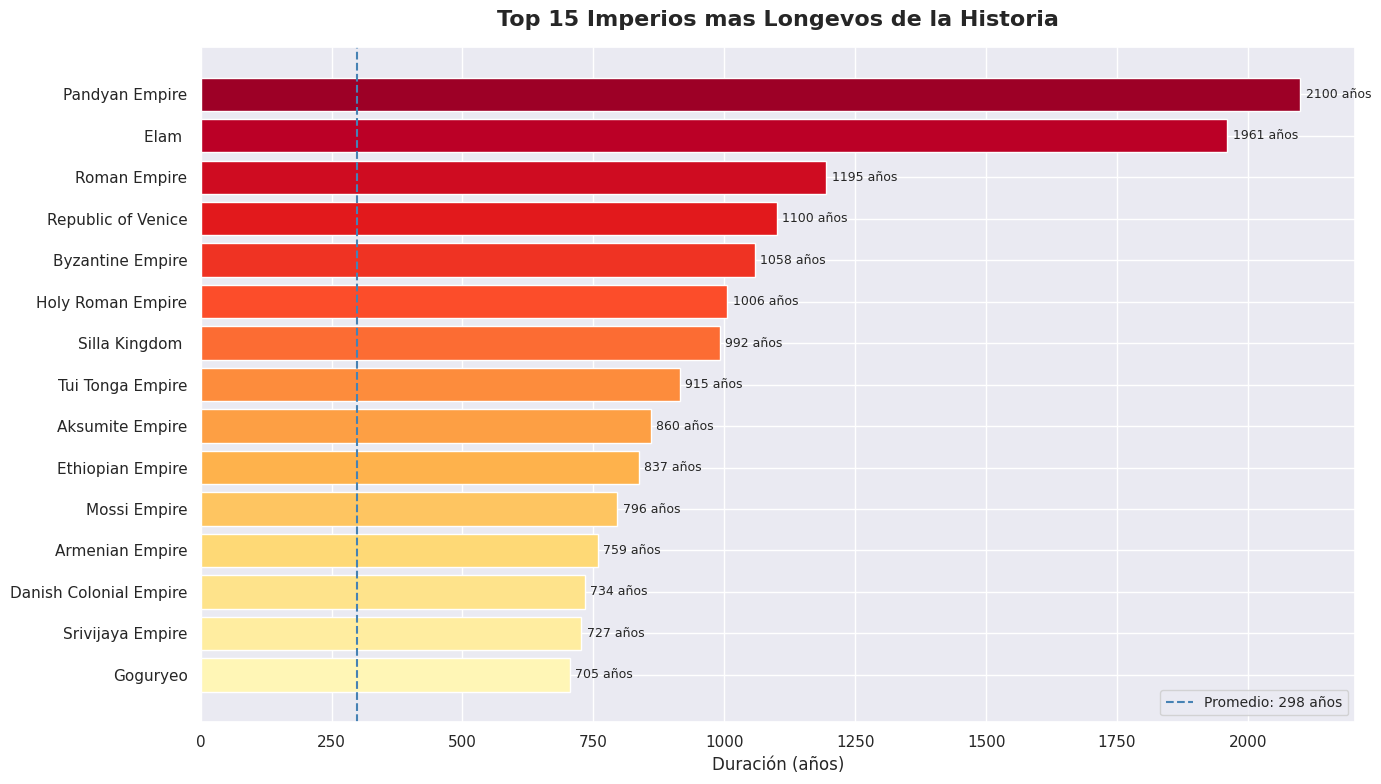

In [10]:
top15_dur = df_imperios.nlargest(15, 'duracion')

plt.figure(figsize=(14, 8))
colores = sns.color_palette("YlOrRd", len(top15_dur))[::-1]
bars = plt.barh(top15_dur['empire'][::-1],
                top15_dur['duracion'][::-1],
                color=colores[::-1], edgecolor='white')

for bar, val in zip(bars, top15_dur['duracion'][::-1]):
    plt.text(bar.get_width() + 10,
             bar.get_y() + bar.get_height()/2,
             f'{val} años', va='center', fontsize=9)

plt.title('Top 15 Imperios mas Longevos de la Historia',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Duración (años)', fontsize=12)
plt.axvline(x=df_imperios['duracion'].mean(), color='steelblue',
            linestyle='--', linewidth=1.5,
            label=f"Promedio: {df_imperios['duracion'].mean():.0f} años")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('top15_longevos.png', dpi=150, bbox_inches='tight')
plt.show()

##  Gráfico 2: Top 15 imperios más extensos

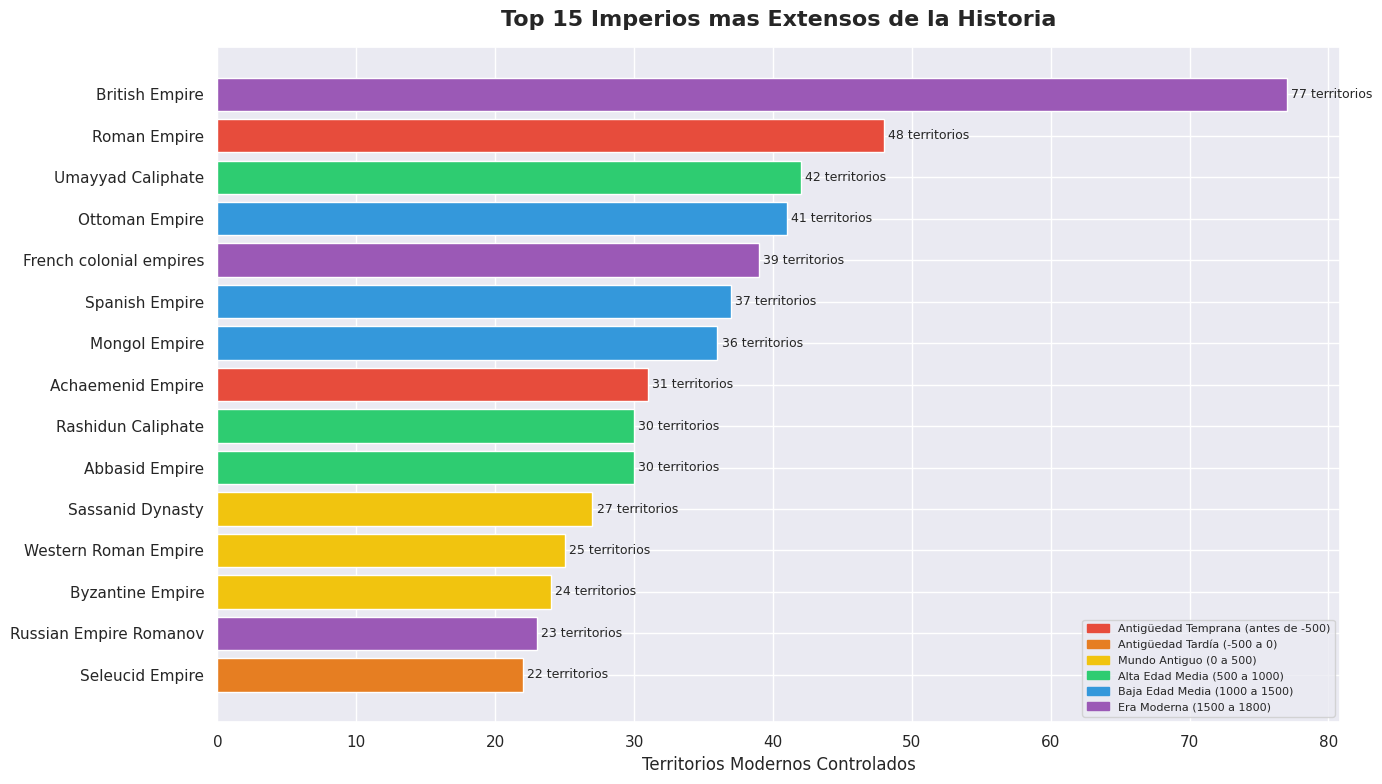

In [11]:
top15_ext = df_imperios.nlargest(15, 'territorios')

colores_map_era = {
    'Antigüedad Temprana (antes de -500)' : '#e74c3c',
    'Antigüedad Tardía (-500 a 0)'        : '#e67e22',
    'Mundo Antiguo (0 a 500)'             : '#f1c40f',
    'Alta Edad Media (500 a 1000)'        : '#2ecc71',
    'Baja Edad Media (1000 a 1500)'       : '#3498db',
    'Era Moderna (1500 a 1800)'           : '#9b59b6',
    'Era Contemporánea (1800+)'           : '#1abc9c'
}

colores = [colores_map_era.get(e, 'gray') for e in top15_ext['era']]

plt.figure(figsize=(14, 8))
bars = plt.barh(top15_ext['empire'][::-1],
                top15_ext['territorios'][::-1],
                color=colores[::-1], edgecolor='white')

for bar, val in zip(bars, top15_ext['territorios'][::-1]):
    plt.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f'{val} territorios', va='center', fontsize=9)

leyenda = [mpatches.Patch(color=v, label=k)
           for k, v in colores_map_era.items()
           if k in top15_ext['era'].values]
plt.legend(handles=leyenda, fontsize=8, loc='lower right')

plt.title('Top 15 Imperios mas Extensos de la Historia',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Territorios Modernos Controlados', fontsize=12)
plt.tight_layout()
plt.savefig('top15_extensos.png', dpi=150, bbox_inches='tight')
plt.show()

##  Gráfico 3: Imperios por región geográfica

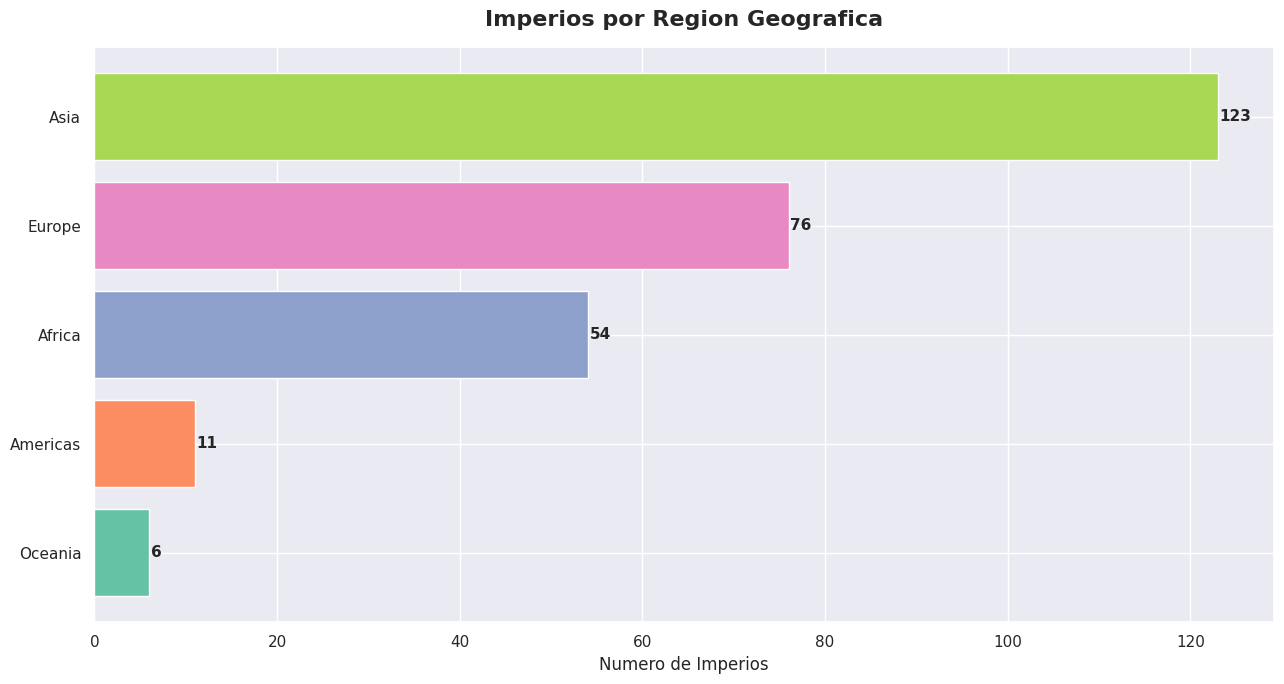

In [12]:
region_counts = df.groupby('geo')['empire'].nunique().sort_values(ascending=True)

plt.figure(figsize=(13, 7))
colores_region = sns.color_palette("Set2", len(region_counts))
bars = plt.barh(region_counts.index, region_counts.values,
                color=colores_region, edgecolor='white')

for bar, val in zip(bars, region_counts.values):
    plt.text(bar.get_width() + 0.2,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=11, fontweight='bold')

plt.title('Imperios por Region Geografica',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Numero de Imperios', fontsize=12)
plt.tight_layout()
plt.savefig('imperios_por_region.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 4: Imperios por era histórica

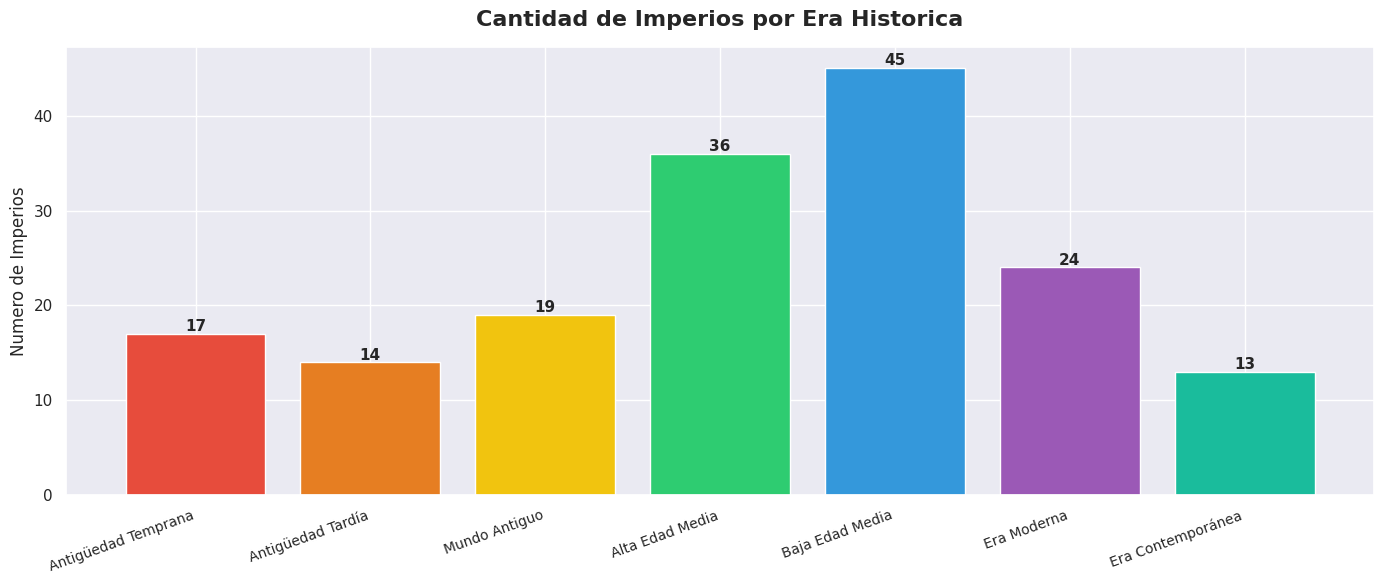

In [13]:
era_orden = [
    'Antigüedad Temprana (antes de -500)',
    'Antigüedad Tardía (-500 a 0)',
    'Mundo Antiguo (0 a 500)',
    'Alta Edad Media (500 a 1000)',
    'Baja Edad Media (1000 a 1500)',
    'Era Moderna (1500 a 1800)',
    'Era Contemporánea (1800+)'
]

era_counts = df_imperios['era'].value_counts().reindex(era_orden).fillna(0)
colores_era = list(colores_map_era.values())

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(era_counts)), era_counts.values,
               color=colores_era, edgecolor='white')

for bar, val in zip(bars, era_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(int(val)), ha='center',
             fontsize=11, fontweight='bold')

plt.xticks(range(len(era_counts)),
           [e.split('(')[0].strip() for e in era_orden],
           rotation=20, ha='right', fontsize=10)
plt.title('Cantidad de Imperios por Era Historica',
          fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Numero de Imperios', fontsize=12)
plt.tight_layout()
plt.savefig('imperios_por_era.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 5: Línea de tiempo de los 20 grandes imperios

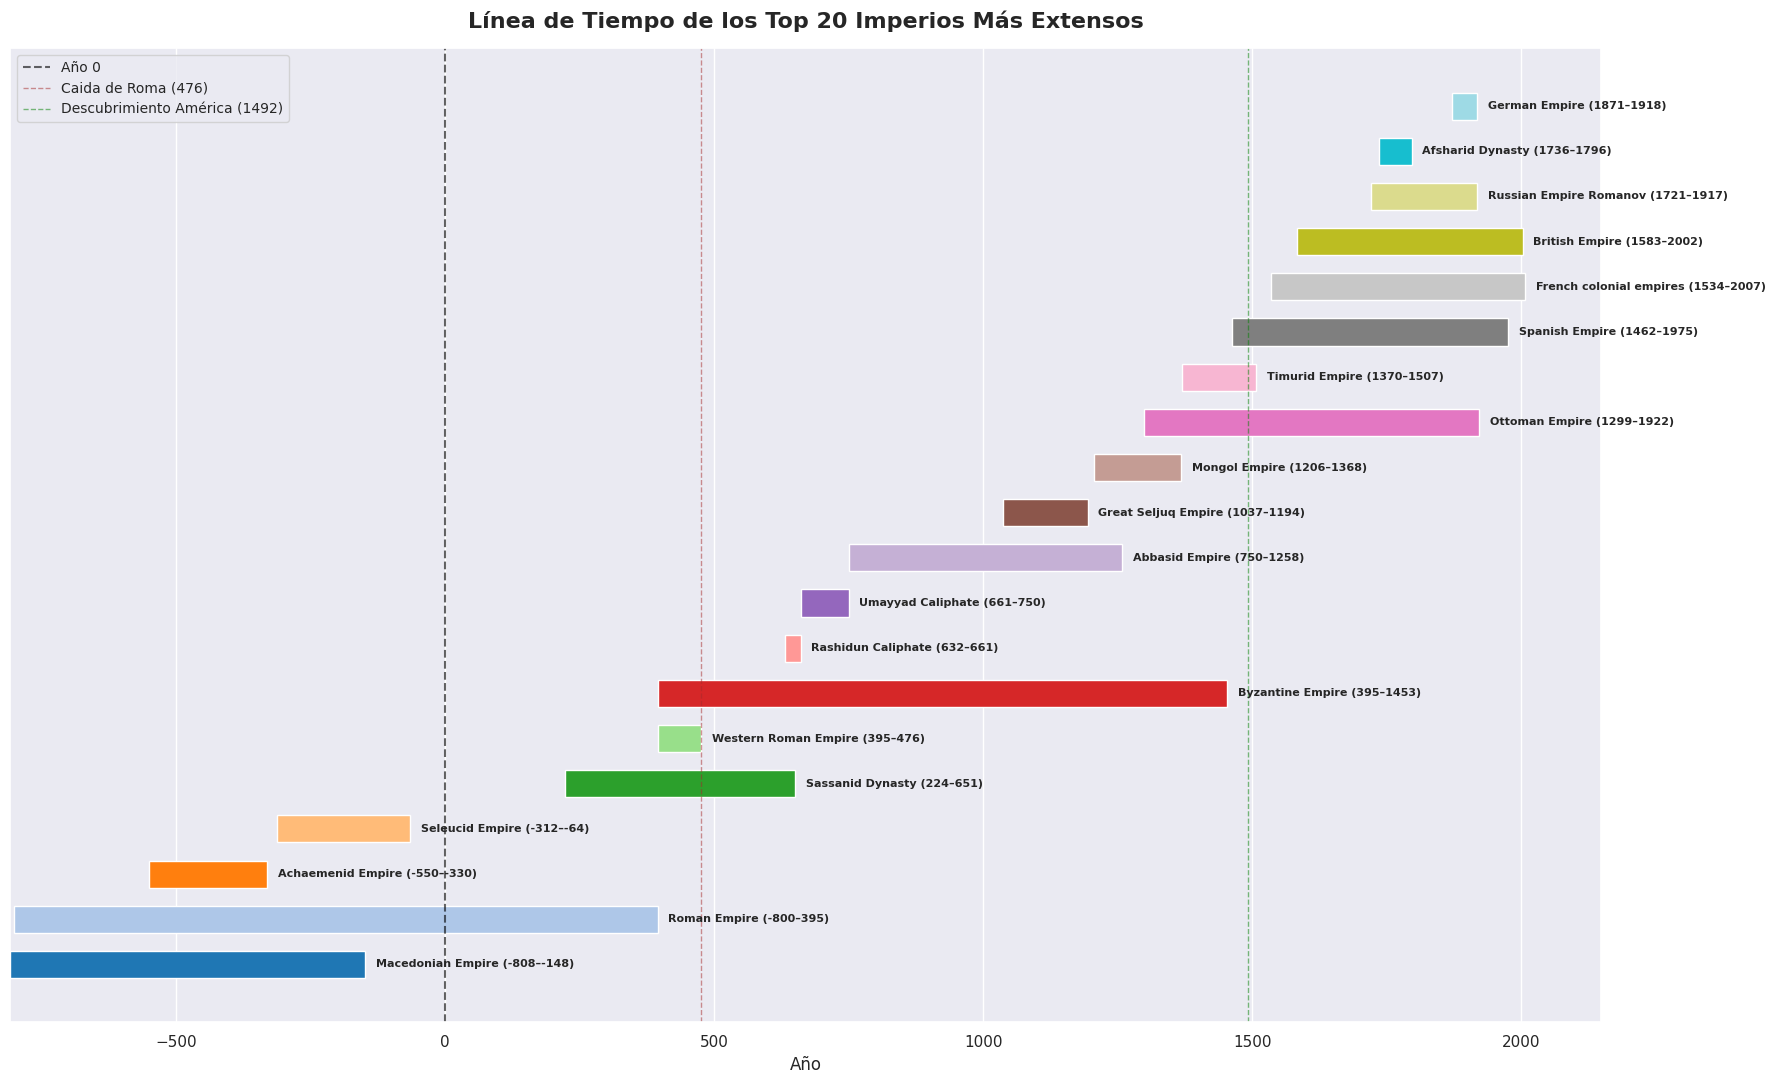

In [18]:
top20_timeline = df_imperios.nlargest(20, 'territorios').sort_values('inicio')

fig, ax = plt.subplots(figsize=(18, 11))
colores_tl = sns.color_palette("tab20", len(top20_timeline))

for i, (_, row) in enumerate(top20_timeline.iterrows()):
    duracion = row['fin'] - row['inicio']
    ax.barh(i, duracion, left=row['inicio'],
            color=colores_tl[i], edgecolor='white', height=0.6)

    # Nombre FUERA de la barra a la derecha
    ax.text(row['fin'] + 20, i,
            f"{row['empire']} ({row['inicio']}–{row['fin']})",
            va='center', fontsize=8, fontweight='bold')

ax.set_yticks([])  # Ocultar eje Y — los nombres ya están en el gráfico
ax.axvline(x=0, color='black', linestyle='--',
           linewidth=1.5, alpha=0.6, label='Año 0')
ax.axvline(x=476, color='brown', linestyle='--',
           linewidth=1, alpha=0.5, label='Caida de Roma (476)')
ax.axvline(x=1492, color='green', linestyle='--',
           linewidth=1, alpha=0.5, label='Descubrimiento América (1492)')

plt.title('Línea de Tiempo de los Top 20 Imperios Más Extensos',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('timeline_top20_imperios.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 6: Serie de tiempo — imperios activos por siglo

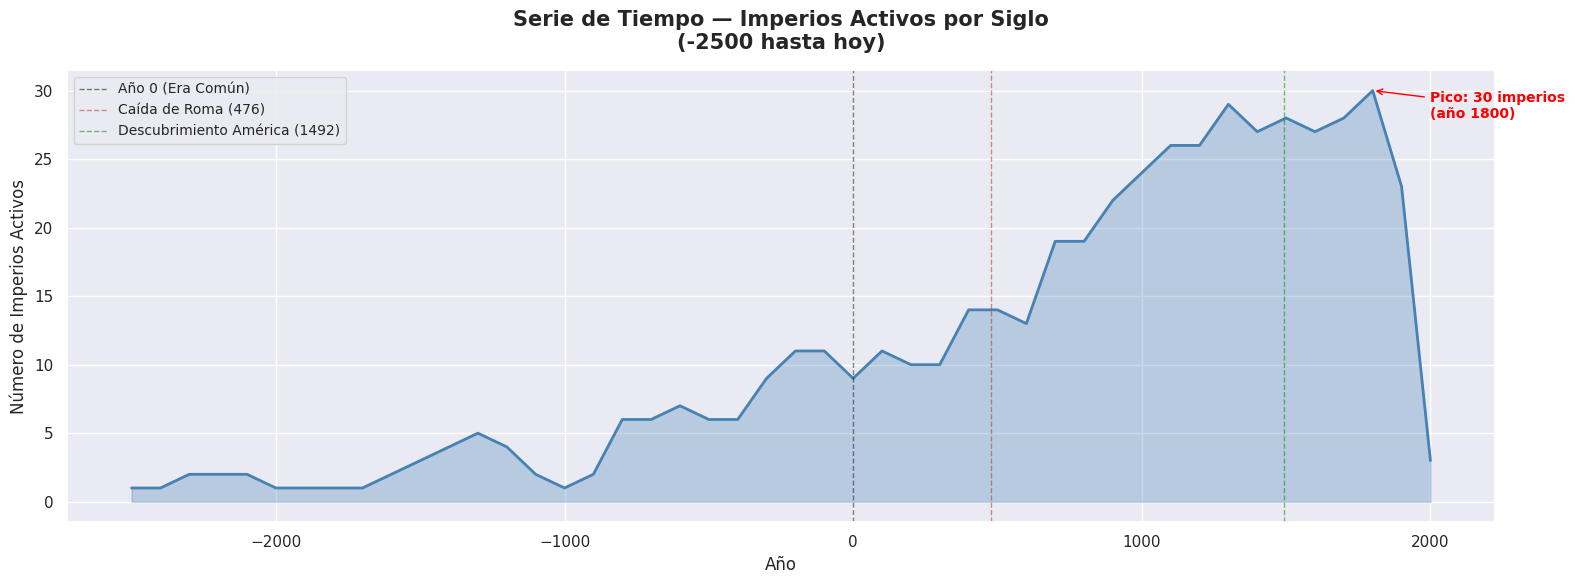

In [26]:
import matplotlib.pyplot as plt

# Crear serie de tiempo por siglo
siglos = range(-2500, 2100, 100)
imperios_activos = []

for siglo in siglos:
    activos = df_imperios[
        (df_imperios['inicio'] <= siglo) &
        (df_imperios['fin'] >= siglo)
    ].shape[0]
    imperios_activos.append(activos)

df_serie = pd.DataFrame({
    'siglo': list(siglos),
    'imperios_activos': imperios_activos
})

plt.figure(figsize=(16, 6))
plt.plot(df_serie['siglo'], df_serie['imperios_activos'],
         color='steelblue', linewidth=2)
plt.fill_between(df_serie['siglo'], df_serie['imperios_activos'],
                 alpha=0.3, color='steelblue')

# Marcar pico histórico
idx_max = df_serie['imperios_activos'].idxmax()
siglo_max = df_serie.loc[idx_max, 'siglo']
valor_max = df_serie.loc[idx_max, 'imperios_activos']
plt.annotate(f'Pico: {valor_max} imperios\n(año {siglo_max})',
             xy=(siglo_max, valor_max),
             xytext=(siglo_max + 200, valor_max - 2),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red', fontweight='bold')

# Referencias históricas
plt.axvline(x=0, color='black', linestyle='--',
            linewidth=1, alpha=0.5, label='Año 0 (Era Común)')
plt.axvline(x=476, color='brown', linestyle='--',
            linewidth=1, alpha=0.5, label='Caída de Roma (476)')
plt.axvline(x=1492, color='green', linestyle='--',
            linewidth=1, alpha=0.5, label='Descubrimiento América (1492)')

plt.title('Serie de Tiempo — Imperios Activos por Siglo\n(-2500 hasta hoy)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Imperios Activos', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('serie_tiempo_imperios.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ Conclusiones de la Fase 3 — Visualizaciones

- El **Pandyan Empire** domina en longevidad con 2100 años
- El **Imperio Británico** dominó 77 territorios modernos
- **Asia** concentra la mayor cantidad de imperios históricos
- La **Baja Edad Media** fue la era con más imperios simultáneos
- La serie de tiempo muestra un pico de actividad imperial
  alrededor del año *1800*
- La caída del Imperio Romano (476) marca un punto de
  inflexión visible en la serie de tiempo

**Siguiente fase:** Series de tiempo avanzadas y ML

# Fase 4 — Series de Tiempo Avanzadas y ML

En esta fase vamos a:
- Analizar patrones cíclicos en el surgimiento de imperios
- Detectar períodos de mayor colapso imperial
- Predecir tendencias usando regresión polinomial
- Clasificar imperios por perfil de poder

## Serie de tiempo: surgimiento vs caída por siglo

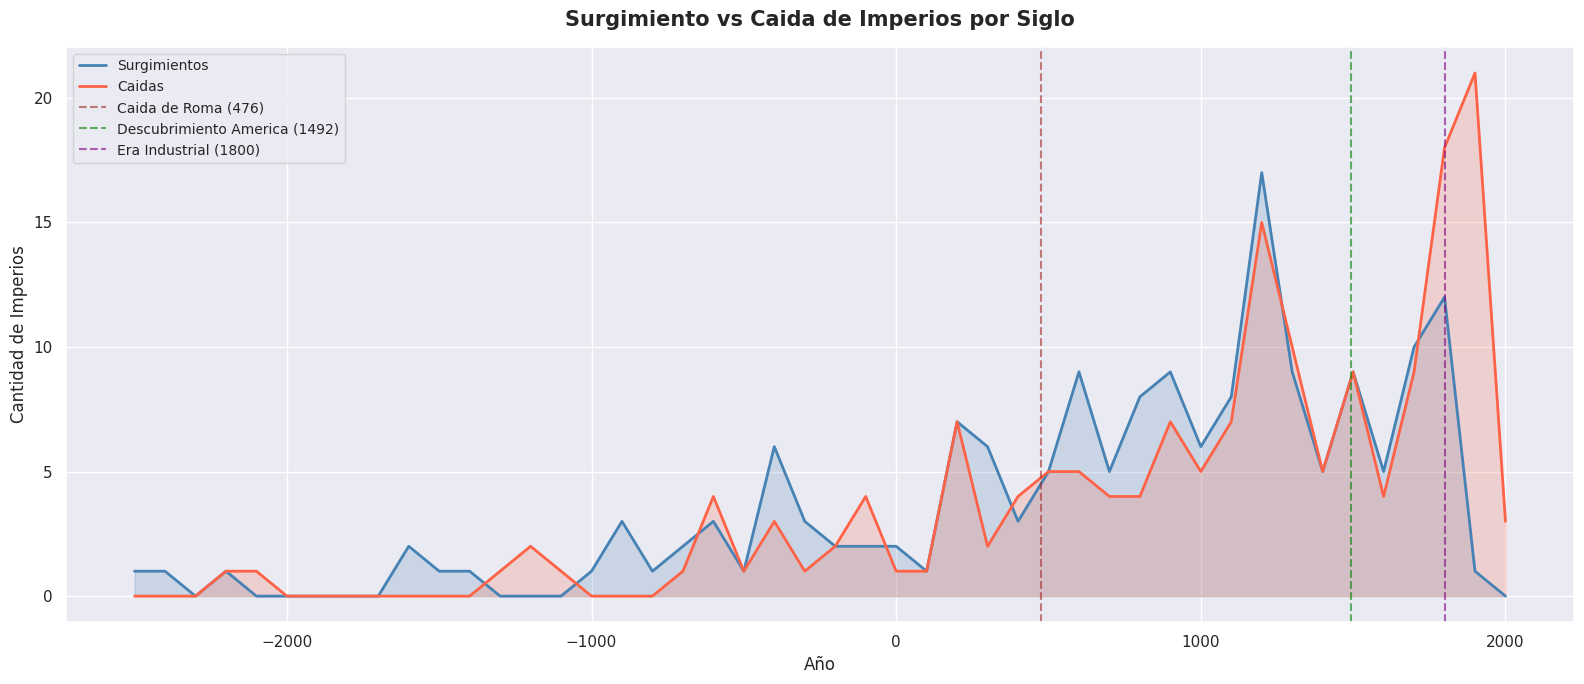

Siglo con más caídas: año 1900
Siglo con más surgimientos: año 1200


In [19]:
siglos = range(-2500, 2100, 100)
surgimientos = []
caidas = []

for siglo in siglos:
    # Imperios que surgieron en ese siglo
    nuevos = df_imperios[
        (df_imperios['inicio'] >= siglo) &
        (df_imperios['inicio'] < siglo + 100)
    ].shape[0]

    # Imperios que cayeron en ese siglo
    caidos = df_imperios[
        (df_imperios['fin'] >= siglo) &
        (df_imperios['fin'] < siglo + 100)
    ].shape[0]

    surgimientos.append(nuevos)
    caidas.append(caidos)

df_ciclo = pd.DataFrame({
    'siglo'       : list(siglos),
    'surgimientos': surgimientos,
    'caidas'      : caidas
})

plt.figure(figsize=(16, 7))
plt.plot(df_ciclo['siglo'], df_ciclo['surgimientos'],
         color='steelblue', linewidth=2, label='Surgimientos')
plt.plot(df_ciclo['siglo'], df_ciclo['caidas'],
         color='tomato', linewidth=2, label='Caidas')
plt.fill_between(df_ciclo['siglo'], df_ciclo['surgimientos'],
                 alpha=0.2, color='steelblue')
plt.fill_between(df_ciclo['siglo'], df_ciclo['caidas'],
                 alpha=0.2, color='tomato')

# Referencias históricas
plt.axvline(x=476, color='brown', linestyle='--',
            linewidth=1.5, alpha=0.6, label='Caida de Roma (476)')
plt.axvline(x=1492, color='green', linestyle='--',
            linewidth=1.5, alpha=0.6, label='Descubrimiento America (1492)')
plt.axvline(x=1800, color='purple', linestyle='--',
            linewidth=1.5, alpha=0.6, label='Era Industrial (1800)')

plt.title('Surgimiento vs Caida de Imperios por Siglo',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Imperios', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('surgimiento_vs_caida.png', dpi=150, bbox_inches='tight')
plt.show()

# Siglo con más caídas
idx_max_caidas = df_ciclo['caidas'].idxmax()
print(f"Siglo con más caídas: año {df_ciclo.loc[idx_max_caidas, 'siglo']}")
print(f"Siglo con más surgimientos: año {df_ciclo.loc[df_ciclo['surgimientos'].idxmax(), 'siglo']}")

## Regresión polinomial sobre imperios activos

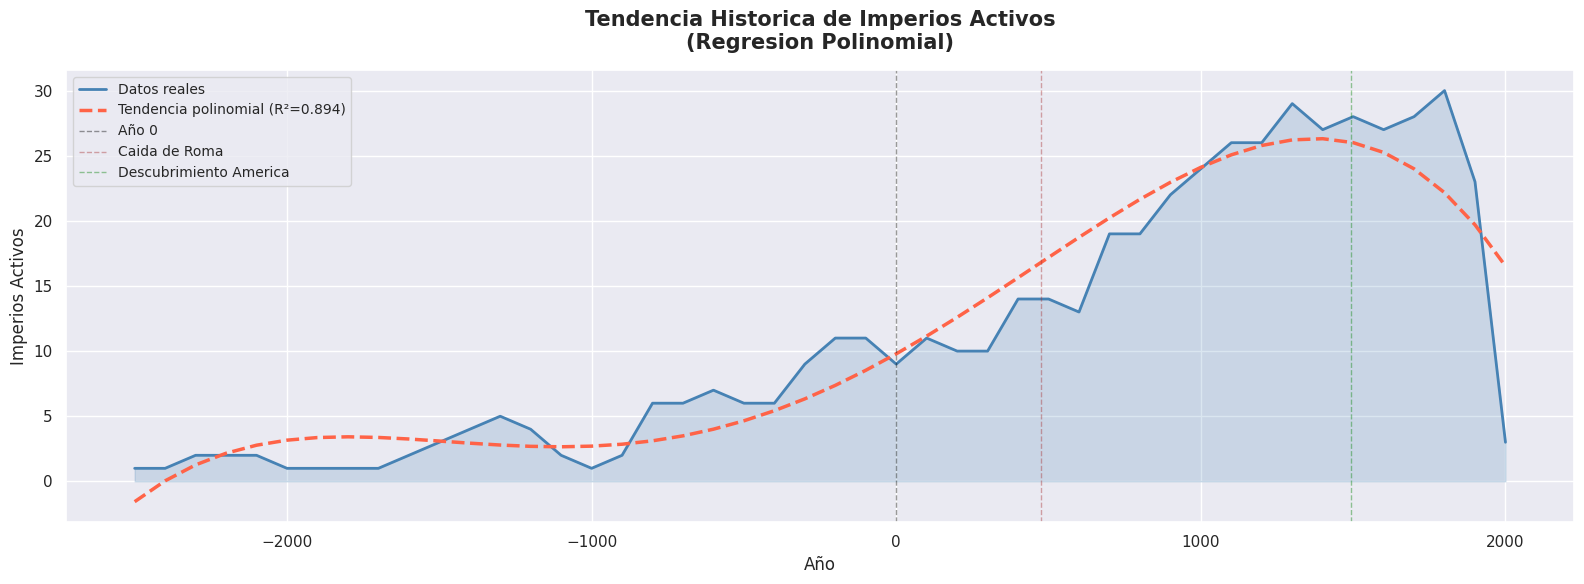

R² del modelo: 0.8944


In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Preparar datos
X_tiempo = df_serie['siglo'].values.reshape(-1, 1)
y_activos = df_serie['imperios_activos'].values

# Modelo polinomial grado 4
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X_tiempo)
modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, y_activos)
y_pred_poly = modelo_poly.predict(X_poly)
r2 = r2_score(y_activos, y_pred_poly)

plt.figure(figsize=(16, 6))
plt.plot(df_serie['siglo'], y_activos,
         color='steelblue', linewidth=2, label='Datos reales')
plt.plot(df_serie['siglo'], y_pred_poly,
         color='tomato', linewidth=2.5,
         linestyle='--', label=f'Tendencia polinomial (R²={r2:.3f})')
plt.fill_between(df_serie['siglo'], y_activos,
                 alpha=0.2, color='steelblue')

plt.axvline(x=0, color='black', linestyle='--',
            linewidth=1, alpha=0.4, label='Año 0')
plt.axvline(x=476, color='brown', linestyle='--',
            linewidth=1, alpha=0.4, label='Caida de Roma')
plt.axvline(x=1492, color='green', linestyle='--',
            linewidth=1, alpha=0.4, label='Descubrimiento America')

plt.title('Tendencia Historica de Imperios Activos\n(Regresion Polinomial)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Imperios Activos', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('regresion_polinomial.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"R² del modelo: {r2:.4f}")

##  Clasificar imperios por perfil de poder

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features para clasificar por perfil de poder
features_poder = ['duracion', 'territorios', 'regiones',
                  'tenia_rey', 'tenia_moneda', 'tenia_comercio']

df_poder = df_imperios[['empire'] + features_poder].dropna().copy()

# Escalar
X_poder = df_poder[features_poder].values
scaler_poder = StandardScaler()
X_poder_scaled = scaler_poder.fit_transform(X_poder)

# K-Means con K=3 (potencias pequeñas, medianas y grandes)
kmeans_poder = KMeans(n_clusters=3, random_state=42, n_init=10)
df_poder['perfil'] = kmeans_poder.fit_predict(X_poder_scaled)

# Etiquetar perfiles por características
perfil_stats = df_poder.groupby('perfil')[features_poder].mean()
print("=== PERFIL PROMEDIO POR CLUSTER ===")
display(perfil_stats.round(2))

=== PERFIL PROMEDIO POR CLUSTER ===


,duracion,territorios,regiones,tenia_rey,tenia_moneda,tenia_comercio
perfil,,,,,,
0,272.76,6.00,1.33,1.0,0.24,0.13
1,406.42,27.38,3.21,1.0,0.71,0.04
2,448.67,8.50,1.67,0.0,0.50,0.67


##  Visualizar perfiles de poder

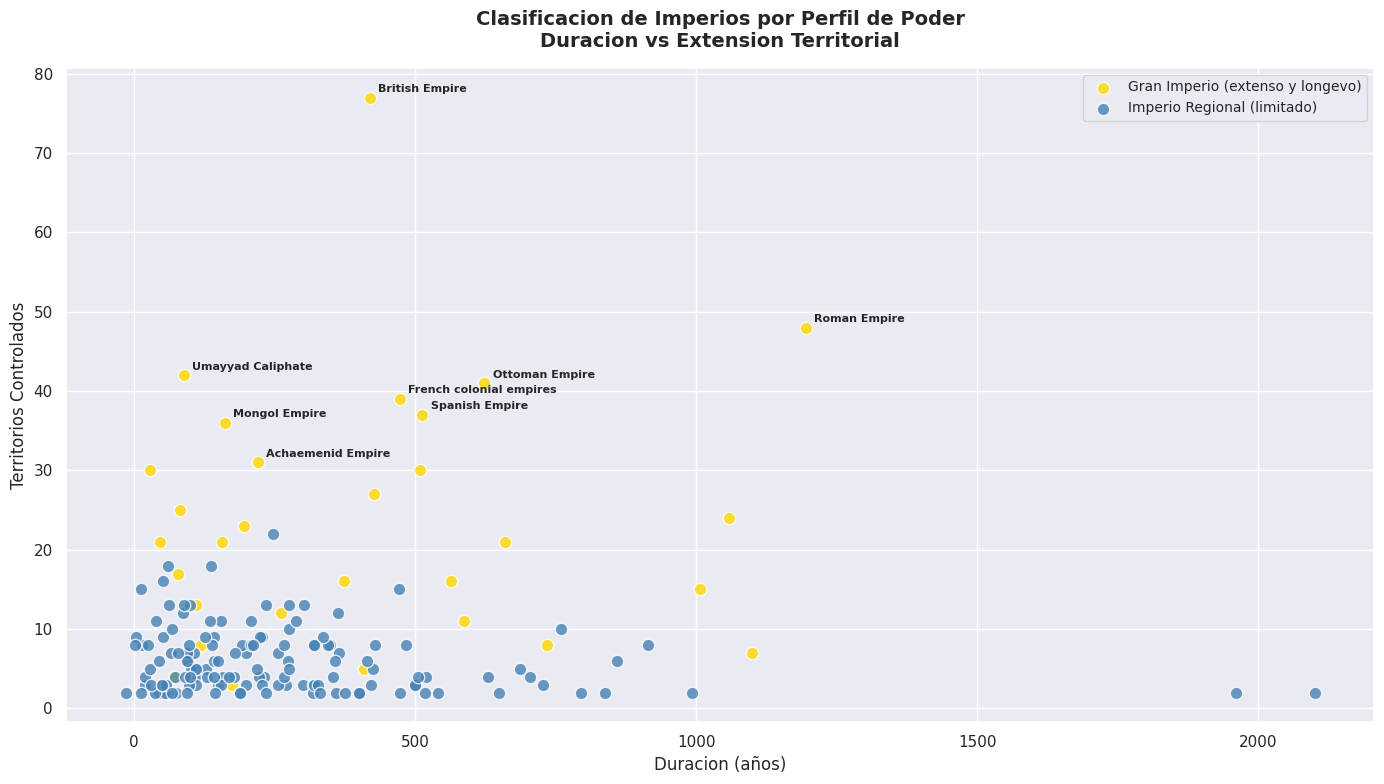

In [22]:
# Renombrar perfiles según características
perfil_nombres = {}
for p in df_poder['perfil'].unique():
    stats = perfil_stats.loc[p]
    if stats['territorios'] >= perfil_stats['territorios'].median():
        if stats['duracion'] >= perfil_stats['duracion'].median():
            perfil_nombres[p] = 'Gran Imperio (extenso y longevo)'
        else:
            perfil_nombres[p] = 'Imperio Expansivo (extenso y breve)'
    else:
        perfil_nombres[p] = 'Imperio Regional (limitado)'

df_poder['perfil_nombre'] = df_poder['perfil'].map(perfil_nombres)

# Gráfico scatter: duración vs territorios coloreado por perfil
plt.figure(figsize=(14, 8))
colores_perfil = {'Gran Imperio (extenso y longevo)' : 'gold',
                  'Imperio Expansivo (extenso y breve)': 'tomato',
                  'Imperio Regional (limitado)'       : 'steelblue'}

for perfil, grupo in df_poder.groupby('perfil_nombre'):
    idx = df_imperios[df_imperios['empire'].isin(grupo['empire'])].index
    datos = df_imperios.loc[idx]
    plt.scatter(datos['duracion'], datos['territorios'],
                color=colores_perfil.get(perfil, 'gray'),
                s=80, alpha=0.8, edgecolor='white',
                label=perfil)

# Etiquetar imperios más destacados
destacados = df_imperios.nlargest(8, 'territorios')
for _, row in destacados.iterrows():
    plt.annotate(row['empire'],
                 (row['duracion'], row['territorios']),
                 textcoords="offset points",
                 xytext=(6, 4), fontsize=8, fontweight='bold')

plt.title('Clasificacion de Imperios por Perfil de Poder\nDuracion vs Extension Territorial',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Duracion (años)', fontsize=12)
plt.ylabel('Territorios Controlados', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('perfiles_poder.png', dpi=150, bbox_inches='tight')
plt.show()

##  ✅ Conclusiones de la Fase 4 — Series de Tiempo y ML

### Series de Tiempo
- El siglo con más **surgimientos** de imperios fue el **año 1200**
  coincidiendo con la expansión del Imperio Mongol, las Cruzadas
  y el auge de los reinos islámicos medievales
- El siglo con más **caídas** fue el **año 1900**
  marcado por el colapso de los grandes imperios coloniales,
  la Primera Guerra Mundial y el inicio de la descolonización
- La regresión polinomial alcanzó un **R²=0.8944** —
  el modelo explica el **89.4%** de la variación histórica
  en el número de imperios activos a lo largo de 4500 años

### Machine Learning — Perfiles de Poder
Se identificaron **3 perfiles naturales** mediante K-Means:

- **Cluster 0 — Imperio Regional:**
  pequeño (6 territorios promedio), duración moderada
  (272 años), poca infraestructura económica —
  imperios de alcance local o regional

- **Cluster 1 — Gran Imperio Territorial:**
  muy extenso (27 territorios), longevo (406 años) y
  con alta adopción de moneda propia (71%) —
  los grandes dominadores de la historia

- **Cluster 2 — Imperio Comercial:**
  moderado en territorio (8) pero el más longevo (448 años)
  y con la mayor actividad comercial (67%) —
  revela que el **comercio fue más determinante que
  el tamaño territorial** para la supervivencia imperial

### Hallazgo clave
> *"Los imperios que priorizaron el comercio duraron más
> que los que priorizaron la expansión territorial"*

**Siguiente fase:** Conclusiones finales y README

# Fase 5 — Conclusiones Finales

---
## Conclusiones Finales del Proyecto

### Hallazgos principales

#### Sobre los imperios más poderosos
- De **168 imperios** analizados a lo largo de 4500 años de historia,
  el **Imperio Pandya** fue el más longevo con **2100 años**
- El **Imperio Británico** fue el más extenso controlando
  **77 territorios** modernos
- El **Imperio Otomano** destacó en ambas categorías:
  623 años de duración y 41 territorios controlados

#### Sobre los patrones históricos
- El siglo **1200** concentró el mayor surgimiento de imperios —
  expansión mongola, cruzadas y auge islámico medieval
- El siglo **1900** registró el mayor colapso imperial —
  fin del colonialismo y Primera Guerra Mundial
- La regresión polinomial explicó el **89.4%** de la
  variación histórica en imperios activos (R²=0.8944)

#### Sobre los perfiles de poder
- Los imperios **comerciales** duraron más que los territoriales
- Tener moneda propia se asocia con mayor extensión territorial
- Los imperios **regionales** sin infraestructura económica
  tuvieron la menor duración promedio (272 años)

### Reflexión final
> *"La historia de los imperios no es solo una historia
> de conquistas — es una historia de economía, comercio
> y adaptación. Los datos revelan que los imperios que
> construyeron redes comerciales sobrevivieron más que
> los que solo expandieron sus fronteras."*

### Limitaciones del análisis
- Los datos de años pueden tener imprecisión histórica
  especialmente en imperios muy antiguos (-2500 a -500)
- La definición de "territorio" usa países modernos
  que no existían en la época de los imperios
- El dataset tiene 168 imperios — existen muchos más
  no documentados digitalmente

### Fuente de datos
[World Empires Dataset — Kaggle](https://www.kaggle.com/datasets/stealthtechnologies/world-empires-dataset)

---
*Proyecto desarrollado como parte del portfolio de Ciencia de Datos*
*Jorge Ojeda — 2026*

## Exportar todas las imágenes

In [29]:
import os

# Crear carpeta images en Drive
ruta_img = '/content/drive/MyDrive/images_imperios/'
os.makedirs(ruta_img, exist_ok=True)

# ── Gráfico 1: Top 15 longevos ────────────────
top15_dur = df_imperios.nlargest(15, 'duracion')
plt.figure(figsize=(14, 8))
colores = sns.color_palette("YlOrRd", len(top15_dur))[::-1]
bars = plt.barh(top15_dur['empire'][::-1],
                top15_dur['duracion'][::-1],
                color=colores[::-1], edgecolor='white')
for bar, val in zip(bars, top15_dur['duracion'][::-1]):
    plt.text(bar.get_width() + 10,
             bar.get_y() + bar.get_height()/2,
             f'{val} años', va='center', fontsize=9)
plt.title('Top 15 Imperios mas Longevos de la Historia',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Duracion (anos)')
plt.axvline(x=df_imperios['duracion'].mean(), color='steelblue',
            linestyle='--', linewidth=1.5,
            label=f"Promedio: {df_imperios['duracion'].mean():.0f} anos")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'top15_longevos.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 1/9 top15_longevos.png")

# ── Gráfico 2: Top 15 extensos ──────────────────
top15_ext = df_imperios.nlargest(15, 'territorios')
colores_map_era = {
    'Antigüedad Temprana (antes de -500)' : '#e74c3c',
    'Antigüedad Tardía (-500 a 0)'        : '#e67e22',
    'Mundo Antiguo (0 a 500)'             : '#f1c40f',
    'Alta Edad Media (500 a 1000)'        : '#2ecc71',
    'Baja Edad Media (1000 a 1500)'       : '#3498db',
    'Era Moderna (1500 a 1800)'           : '#9b59b6',
    'Era Contemporánea (1800+)'           : '#1abc9c'
}
colores = [colores_map_era.get(e, 'gray') for e in top15_ext['era']]
plt.figure(figsize=(14, 8))
bars = plt.barh(top15_ext['empire'][::-1],
                top15_ext['territorios'][::-1],
                color=colores[::-1], edgecolor='white')
for bar, val in zip(bars, top15_ext['territorios'][::-1]):
    plt.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f'{val} territorios', va='center', fontsize=9)
leyenda = [mpatches.Patch(color=v, label=k)
           for k, v in colores_map_era.items()
           if k in top15_ext['era'].values]
plt.legend(handles=leyenda, fontsize=8, loc='lower right')
plt.title('Top 15 Imperios mas Extensos de la Historia',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Territorios Modernos Controlados')
plt.tight_layout()
plt.savefig(ruta_img + 'top15_extensos.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 2/9 top15_extensos.png")

# ── Gráfico 3: Imperios por región ───────────────────
region_counts = df.groupby('geo')['empire'].nunique().sort_values(ascending=True)
plt.figure(figsize=(13, 7))
colores_region = sns.color_palette("Set2", len(region_counts))
bars = plt.barh(region_counts.index, region_counts.values,
                color=colores_region, edgecolor='white')
for bar, val in zip(bars, region_counts.values):
    plt.text(bar.get_width() + 0.2,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=11, fontweight='bold')
plt.title('Imperios por Region Geografica',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Numero de Imperios')
plt.tight_layout()
plt.savefig(ruta_img + 'imperios_por_region.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 3/9 imperios_por_region.png")

# ── Gráfico 4: Imperios por era ───────────────────
era_orden = [
    'Antigüedad Temprana (antes de -500)',
    'Antigüedad Tardía (-500 a 0)',
    'Mundo Antiguo (0 a 500)',
    'Alta Edad Media (500 a 1000)',
    'Baja Edad Media (1000 a 1500)',
    'Era Moderna (1500 a 1800)',
    'Era Contemporánea (1800+)'
]
era_counts = df_imperios['era'].value_counts().reindex(era_orden).fillna(0)
colores_era = list(colores_map_era.values())
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(era_counts)), era_counts.values,
               color=colores_era, edgecolor='white')
for bar, val in zip(bars, era_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(int(val)), ha='center', fontsize=11, fontweight='bold')
plt.xticks(range(len(era_counts)),
           [e.split('(')[0].strip() for e in era_orden],
           rotation=20, ha='right', fontsize=10)
plt.title('Cantidad de Imperios por Era Historica',
          fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Numero de Imperios')
plt.tight_layout()
plt.savefig(ruta_img + 'imperios_por_era.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 4/9 imperios_por_era.png")

# ── Gráfico 5: Línea de tiempo ───────────────────
top20_timeline = df_imperios.nlargest(20, 'territorios').sort_values('inicio')
fig, ax = plt.subplots(figsize=(18, 11))
colores_tl = sns.color_palette("tab20", len(top20_timeline))
for i, (_, row) in enumerate(top20_timeline.iterrows()):
    duracion = row['fin'] - row['inicio']
    ax.barh(i, duracion, left=row['inicio'],
            color=colores_tl[i], edgecolor='white', height=0.6)
    ax.text(row['fin'] + 20, i,
            f"{row['empire']} ({row['inicio']}–{row['fin']})",
            va='center', fontsize=8, fontweight='bold')
ax.set_yticks([])
ax.axvline(x=0, color='black', linestyle='--',
           linewidth=1.5, alpha=0.6, label='Año 0')
ax.axvline(x=476, color='brown', linestyle='--',
           linewidth=1, alpha=0.5, label='Caida de Roma (476)')
ax.axvline(x=1492, color='green', linestyle='--',
           linewidth=1, alpha=0.5, label='Descubrimiento América (1492)')
ax.set_xlabel('Año', fontsize=12)
ax.set_title('Línea de Tiempo — Top 20 Imperios mas Extensos',
             fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(df_imperios['inicio'].min() - 100,
            top20_timeline['fin'].max() + 500)
plt.tight_layout()
plt.savefig(ruta_img + 'linea_tiempo.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 5/9 linea_tiempo.png")

# ── Gráfico 6: Serie de tiempo ───────────────────
# Crear serie de tiempo por siglo
siglos = range(-2500, 2100, 100)
imperios_activos = []

for siglo in siglos:
    activos = df_imperios[
        (df_imperios['inicio'] <= siglo) &
        (df_imperios['fin'] >= siglo)
    ].shape[0]
    imperios_activos.append(activos)

df_serie = pd.DataFrame({
    'siglo': list(siglos),
    'imperios_activos': imperios_activos
})

plt.figure(figsize=(16, 6))
plt.plot(df_serie['siglo'], df_serie['imperios_activos'],
         color='steelblue', linewidth=2)
plt.fill_between(df_serie['siglo'], df_serie['imperios_activos'],
                 alpha=0.3, color='steelblue')

# Marcar pico histórico
idx_max = df_serie['imperios_activos'].idxmax()
siglo_max = df_serie.loc[idx_max, 'siglo']
valor_max = df_serie.loc[idx_max, 'imperios_activos']
plt.annotate(f'Pico: {valor_max} imperios\n(año {siglo_max})',
             xy=(siglo_max, valor_max),
             xytext=(siglo_max + 200, valor_max - 2),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red', fontweight='bold')

# Referencias históricas
plt.axvline(x=0, color='black', linestyle='--',
            linewidth=1, alpha=0.5, label='Año 0 (Era Comôn)')
plt.axvline(x=476, color='brown', linestyle='--',
            linewidth=1, alpha=0.5, label='Caída de Roma (476)')
plt.axvline(x=1492, color='green', linestyle='--',
            linewidth=1, alpha=0.5, label='Descubrimiento América (1492)')

plt.title('Serie de Tiempo — Imperios Activos por Siglo\n(-2500 hasta hoy)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Imperios Activos', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'serie_tiempo_imperios.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 6/9 serie_tiempo_imperios.png")

# ── Gráfico 7: Surgimiento vs caída ───────────────
import matplotlib.pyplot as plt

siglos = range(-2500, 2100, 100)
surgimientos = []
caidas = []

for siglo in siglos:
    # Imperios que surgieron en ese siglo
    nuevos = df_imperios[
        (df_imperios['inicio'] >= siglo) &
        (df_imperios['inicio'] < siglo + 100)
    ].shape[0]

    # Imperios que cayeron en ese siglo
    caidos = df_imperios[
        (df_imperios['fin'] >= siglo) &
        (df_imperios['fin'] < siglo + 100)
    ].shape[0]

    surgimientos.append(nuevos)
    caidas.append(caidos)

df_ciclo = pd.DataFrame({
    'siglo'       : list(siglos),
    'surgimientos': surgimientos,
    'caidas'      : caidas
})

plt.figure(figsize=(16, 7))
plt.plot(df_ciclo['siglo'], df_ciclo['surgimientos'],
         color='steelblue', linewidth=2, label='Surgimientos')
plt.plot(df_ciclo['siglo'], df_ciclo['caidas'],
         color='tomato', linewidth=2, label='Caidas')
plt.fill_between(df_ciclo['siglo'], df_ciclo['surgimientos'],
                 alpha=0.2, color='steelblue')
plt.fill_between(df_ciclo['siglo'], df_ciclo['caidas'],
                 alpha=0.2, color='tomato')

# Referencias históricas
plt.axvline(x=476, color='brown', linestyle='--',
            linewidth=1.5, alpha=0.6, label='Caida de Roma (476)')
plt.axvline(x=1492, color='green', linestyle='--',
            linewidth=1.5, alpha=0.6, label='Descubrimiento America (1492)')
plt.axvline(x=1800, color='purple', linestyle='--',
            linewidth=1.5, alpha=0.6, label='Era Industrial (1800)')

plt.title('Surgimiento vs Caida de Imperios por Siglo',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Imperios', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'surgimiento_vs_caida.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 7/9 surgimiento_vs_caida.png")

# ── Gráfico 8: Regresión polinomial ──────────────
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Preparar datos
X_tiempo = df_serie['siglo'].values.reshape(-1, 1)
y_activos = df_serie['imperios_activos'].values

# Modelo polinomial grado 4
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X_tiempo)
modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, y_activos)
y_pred_poly = modelo_poly.predict(X_poly)
r2 = r2_score(y_activos, y_pred_poly)

plt.figure(figsize=(16, 6))
plt.plot(df_serie['siglo'], y_activos,
         color='steelblue', linewidth=2, label='Datos reales')
plt.plot(df_serie['siglo'], y_pred_poly,
         color='tomato', linewidth=2.5,
         linestyle='--', label=f'Tendencia polinomial (R²={r2:.3f})')
plt.fill_between(df_serie['siglo'], y_activos,
                 alpha=0.2, color='steelblue')

plt.axvline(x=0, color='black', linestyle='--',
            linewidth=1, alpha=0.4, label='Año 0')
plt.axvline(x=476, color='brown', linestyle='--',
            linewidth=1, alpha=0.4, label='Caida de Roma')
plt.axvline(x=1492, color='green', linestyle='--',
            linewidth=1, alpha=0.4, label='Descubrimiento America')

plt.title('Tendencia Historica de Imperios Activos\n(Regresion Polinomial)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Imperios Activos', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'regresion_polinomial.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 8/9 regresion_polinomial.png")

# ── Gráfico 9: Perfiles de poder ──────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features para clasificar por perfil de poder
features_poder = ['duracion', 'territorios', 'regiones',
                  'tenia_rey', 'tenia_moneda', 'tenia_comercio']

df_poder = df_imperios[['empire'] + features_poder].dropna().copy()

# Escalar
X_poder = df_poder[features_poder].values
scaler_poder = StandardScaler()
X_poder_scaled = scaler_poder.fit_transform(X_poder)

# K-Means con K=3 (potencias pequeñas, medianas y grandes)
kmeans_poder = KMeans(n_clusters=3, random_state=42, n_init=10)
df_poder['perfil'] = kmeans_poder.fit_predict(X_poder_scaled)

# Etiquetar perfiles por características
perfil_stats = df_poder.groupby('perfil')[features_poder].mean()

# Renombrar perfiles segón características
perfil_nombres = {}
for p in df_poder['perfil'].unique():
    stats = perfil_stats.loc[p]
    if stats['territorios'] >= perfil_stats['territorios'].median():
        if stats['duracion'] >= perfil_stats['duracion'].median():
            perfil_nombres[p] = 'Gran Imperio (extenso y longevo)'
        else:
            perfil_nombres[p] = 'Imperio Expansivo (extenso y breve)'
    else:
        perfil_nombres[p] = 'Imperio Regional (limitado)'

df_poder['perfil_nombre'] = df_poder['perfil'].map(perfil_nombres)

# Gráfico scatter: duración vs territorios coloreado por perfil
plt.figure(figsize=(14, 8))
colores_perfil = {'Gran Imperio (extenso y longevo)' : 'gold',
                  'Imperio Expansivo (extenso y breve)': 'tomato',
                  'Imperio Regional (limitado)'       : 'steelblue'}

for perfil, grupo in df_poder.groupby('perfil_nombre'):
    idx = df_imperios[df_imperios['empire'].isin(grupo['empire'])].index
    datos = df_imperios.loc[idx]
    plt.scatter(datos['duracion'], datos['territorios'],
                color=colores_perfil.get(perfil, 'gray'),
                s=80, alpha=0.8, edgecolor='white',
                label=perfil)

# Etiquetar imperios más destacados
destacados = df_imperios.nlargest(8, 'territorios')
for _, row in destacados.iterrows():
    plt.annotate(row['empire'],
                 (row['duracion'], row['territorios']),
                 textcoords="offset points",
                 xytext=(6, 4), fontsize=8, fontweight='bold')

plt.title('Clasificacion de Imperios por Perfil de Poder\nDuracion vs Extension Territorial',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Duracion (años)', fontsize=12)
plt.ylabel('Territorios Controlados', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'perfiles_poder.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 9/9 perfiles_poder.png")

✅ 1/9 top15_longevos.png
✅ 2/9 top15_extensos.png
✅ 3/9 imperios_por_region.png
✅ 4/9 imperios_por_era.png
✅ 5/9 linea_tiempo.png
✅ 6/9 serie_tiempo_imperios.png
✅ 7/9 surgimiento_vs_caida.png
✅ 8/9 regresion_polinomial.png
✅ 9/9 perfiles_poder.png
